# Stage 2: Task-Specific AQG Training (Adapter-Based)

**Version**: 3.0 (Adapter Layers - No LoRA)

Notebook ini melatih model IndoNanoT5 untuk task AQG menggunakan **Adapter Layers** (bukan LoRA).

**Key Differences from v2:**
- ✅ Adapter Layers (0.95% trainable params) vs LoRA (0.36%)
- ✅ 99.6% performance dari full fine-tuning
- ✅ No inference latency overhead
- ✅ More stable untuk small datasets
- ✅ 8 epochs training (vs 3 epochs di v2)

**Configuration:**
- Adapter dimension: d=64 (reduction_factor=12)
- Trainable parameters: ~2.4M (0.95% dari 248M) ✅ VERIFIED
- Learning rate: 1e-4
- Batch size: 4 + gradient accumulation 2 (effective=8)
- Epochs: 8
- Memory: ~12-14GB (safe untuk T4)

**Note:** 2.4M (0.95%) is CORRECT for Pfeiffer adapter d=64. The 8.9M (3.6%) often mentioned refers to different configurations (d=256 or Houlsby adapter)

**Expected Results:**
- Training loss: 39 → 2-5
- BLEU-4: 0.005 → 0.20-0.28
- ROUGE-L: 0.0 → 0.25-0.35
- Training time: ~6-8 jam pada T4 GPU

**Reference:** Based on Houlsby et al. (2019) - Parameter-Efficient Transfer Learning for NLP

## 1. Setup Environment

In [1]:
# Install dependencies
!pip install -q adapters
!pip install -q transformers datasets accelerate
!pip install -q evaluate rouge_score bert_score
print('✓ Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 119.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.2 MB/s eta 0:00:00
✓ Dependencies installed


In [2]:
# Cek versi semua library yang terinstall
import importlib
import sys, torch, platform

# Add this line
import adapters

# Keep these
from adapters import AutoAdapterModel, AdapterConfig
from transformers import AutoTokenizer


libs = [
    "adapters",
    "transformers",
    "datasets",
    "accelerate",
    "evaluate",
    "torch",
    "tokenizers",
    "rouge_score",
    "bert_score",
]

print(f"Python:  {sys.version}")
print(f"OS:      {platform.system()}")
print(f"Torch:   {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}\n")

print("=== Library Versions ===")
for lib in libs:
    try:
        mod = importlib.import_module(lib.replace("-", "_"))
        version = getattr(mod, "__version__", "unknown")
        print(f"  {lib:<20} {version}")
    except ImportError:
        print(f"  {lib:<20} NOT INSTALLED")

if torch.cuda.is_available():
    print(f"\n  {'cuda version':<20} {torch.version.cuda}")
    print(f"  {'gpu name':<20} {torch.cuda.get_device_name(0)}")

Python:  3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
OS:      Linux
Torch:   2.10.0+cu128
CUDA:    True

=== Library Versions ===
  adapters             1.3.0
  transformers         4.57.6
  datasets             4.0.0
  accelerate           1.13.0
  evaluate             0.4.6
  torch                2.10.0+cu128
  tokenizers           0.22.2
  rouge_score          unknown
  bert_score           0.3.12

  cuda version         12.8
  gpu name             Tesla T4


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✓ Google Drive mounted')

Mounted at /content/drive
✓ Google Drive mounted


In [4]:
# Setup paths and extract source code
import os, sys, zipfile, shutil

DRIVE_ROOT = '/content/drive/MyDrive/dataset_aqg'
sys.path.insert(0, '/content')

# Extract src if not exists
if not os.path.exists('/content/src'):
    shutil.copy(f'{DRIVE_ROOT}/src_finetuned.zip', '/content/src_finetuned.zip')
    with zipfile.ZipFile('/content/src_finetuned.zip', 'r') as z:
        z.extractall('/content/')
    print('✓ src extracted')
else:
    print('✓ src already exists')

print(f'✓ DRIVE_ROOT: {DRIVE_ROOT}')
print(f'✓ sys.path[0]: {sys.path[0]}')

✓ src extracted
✓ DRIVE_ROOT: /content/drive/MyDrive/dataset_aqg
✓ sys.path[0]: /content


In [5]:
# Verify GPU availability
import torch

if not torch.cuda.is_available():
    raise RuntimeError('GPU not available! Go to Runtime > Change runtime type > T4 GPU')

print(f'✓ GPU: {torch.cuda.get_device_name(0)}')
print(f'✓ Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✓ GPU: Tesla T4
✓ Memory: 15.6 GB


## 2. Load Model with Adapter Layers

**Using**: `src.finetuned.utils.adapter_loader` (modular approach!)

In [6]:
from src.finetuned.utils.adapter_loader import load_model_with_adapter, print_adapter_info

# Load model with adapter layers
model, tokenizer = load_model_with_adapter(
    model_name='LazarusNLP/IndoNanoT5-base',
    adapter_name='mcq_generation',
    adapter_config='pfeiffer',
    reduction_factor=12,  # d=64
    device='cuda'
)

# Print detailed info
trainable, total = print_adapter_info(model, tokenizer)


LOADING MODEL WITH ADAPTER LAYERS
Loading base model: LazarusNLP/IndoNanoT5-base
  Using NEW adapters library (not adapter-transformers)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

⚠ AutoAdapterModel failed: The state dictionary of the model you are trying to load is corrupted. Are you s...
  Trying alternative: Load with transformers + adapters.init()


generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

✓ Base model loaded with transformers + adapters.init()
✓ Adapter added: pfeiffer config, d=64
✓ Adapter activated for training
✓ Model moved to GPU
  GPU allocated: 1.00 GB

MODEL INFORMATION

Parameters:
  Trainable: 2,379,264 (0.95%)
  Total:     249,957,120
  Frozen:    247,577,856

Tokenizer:
  Vocab size: 32000
  Pad token:  <pad> (ID: 0)
  EOS token:  </s> (ID: 1)


## 3. Load Dataset

**Using**: `src.finetuned.data.dataset_loader` (reusable module)

In [7]:
from src.finetuned.data.dataset_loader import DatasetLoader

loader = DatasetLoader()
TASK_DIR = '/content/dataset_aqg/dataset-task-spesifc/'

# Copy dataset from Drive if needed
if not os.path.exists(TASK_DIR + 'train.jsonl'):
    drive_task = f'{DRIVE_ROOT}/dataset-task-spesifc'
    os.makedirs(TASK_DIR, exist_ok=True)
    for f in ['train.jsonl', 'validation.jsonl', 'test.jsonl']:
        shutil.copy(f'{drive_task}/{f}', f'{TASK_DIR}{f}')
    print('✓ Dataset copied from Drive')

# Load datasets
train_dataset = loader.load_dataset(TASK_DIR, split='train')
val_dataset = loader.load_dataset(TASK_DIR, split='validation')
test_dataset = loader.load_dataset(TASK_DIR, split='test')

print(f'\nDataset loaded:')
print(f'  Train: {len(train_dataset)} samples')
print(f'  Val:   {len(val_dataset)} samples')
print(f'  Test:  {len(test_dataset)} samples')

# Validate and preview
validation_results = loader.validate_dataset(train_dataset)

sample = train_dataset[0]
print('\n=== Sample Entry ===')
print(f"Input: {sample['input']}...")
output_field = 'target' if 'target' in sample else 'output'
print(f"Output: {sample[output_field]}...")
print(f'\n✓ Dataset ready (supports both v2 and v3 formats)')

✓ Dataset copied from Drive


Generating train split: 0 examples [00:00, ? examples/s]

✓ Loaded 2812 entries from /content/dataset_aqg/dataset-task-spesifc/train.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

✓ Loaded 351 entries from /content/dataset_aqg/dataset-task-spesifc/validation.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

✓ Loaded 352 entries from /content/dataset_aqg/dataset-task-spesifc/test.jsonl

Dataset loaded:
  Train: 2812 samples
  Val:   351 samples
  Test:  352 samples
✓ Using output field: 'output'

=== Dataset Validation Summary ===
Total Entries: 2812
Duplicate Count: 0
Avg Input Length: 190.77 chars
Avg Target Length: 234.73 chars
Has Metadata: True
✓ No duplicates found

=== Sample Entry ===
Input: buat_soal_pilihan_ganda: Deklarasi matriks dengan nilai default menggunakan nested list comprehension. Format umumnya adalah [[default_val for j in range(m)] for i in range(n)] di mana n adalah jumlah baris dan m adalah jumlah kolom....
Output: question: Apa format umum deklarasi matriks dengan nilai default?
answer: [[default_val for j in range(m)] for i in range(n)]
distractors: [[default_val for i in range(n)] for j in range(m)] | [default_val for i in range(n*m)] | [[default_val] * m] * n...

✓ Dataset ready (supports both v2 and v3 formats)


## 4. Baseline Evaluation

**Using**: `src.finetuned.evaluation` modules

In [8]:
from src.finetuned.evaluation.metrics_calculator import MetricsCalculator
from src.finetuned.evaluation.model_evaluator import ModelEvaluator

metrics_calc = MetricsCalculator()
evaluator = ModelEvaluator(
    model=model,
    tokenizer=tokenizer,
    metrics_calculator=metrics_calc
)

print('Computing baseline metrics (10 samples)...')
baseline_metrics = evaluator.evaluate_on_test_set(
    test_dataset=val_dataset,
    num_beams=4,
    include_bertscore=False,
    max_samples=10
)

print(f"\nBaseline Metrics:")
print(f"  BLEU-4:  {baseline_metrics.get('bleu_4', 0):.4f}")
print(f"  ROUGE-L: {baseline_metrics.get('rouge_l', 0):.4f}")

Computing baseline metrics (10 samples)...

EVALUATING ON TEST SET

Evaluating 10 samples...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)


  Processed 10/10 samples...
✓ Generated 10 predictions
Computing metrics for 10 samples...
  Computing BLEU...


  Computing ROUGE...


  Computing Diversity...
✓ All metrics computed

Test Set Evaluation Results

BLEU Scores:
  BLEU:     0.0233
  BLEU-1:   0.0993
  BLEU-2:   0.0331
  BLEU-3:   0.0124
  BLEU-4:   0.0072

ROUGE Scores:
  ROUGE-1:  0.1687
  ROUGE-2:  0.0462
  ROUGE-L:  0.1446

Diversity:
  Distinct-1: 0.3670
  Distinct-2: 0.7037


Baseline Metrics:
  BLEU-4:  0.0072
  ROUGE-L: 0.1446


## 5. Configure Training

**Using**: `src.finetuned.training.adapter_trainer` (modular approach!)

In [9]:
from src.finetuned.training.adapter_trainer import AdapterTrainer

CHECKPOINT_DIR = '/content/drive/MyDrive/dataset_aqg/checkpoints/adapter_v3'

# Initialize trainer
trainer = AdapterTrainer(
    model=model,
    tokenizer=tokenizer,
    metrics_calculator=metrics_calc,
    output_dir=CHECKPOINT_DIR,
    max_length=512
)

# Setup training configuration
training_args = trainer.setup_training(
    num_train_epochs=8,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-4,
    warmup_steps=50,
    weight_decay=0.01
)

print('\n✓ Trainer configured')
print(f'  Checkpoints will be saved to: {CHECKPOINT_DIR}')


TRAINING CONFIGURATION
Epochs: 8
Batch size: 4
Effective batch size: 8
Learning rate: 0.0001
Warmup steps: 50
FP16: True
Gradient checkpointing: True

✓ Trainer configured
  Checkpoints will be saved to: /content/drive/MyDrive/dataset_aqg/checkpoints/adapter_v3


## 6. Start Training

**⚠️ This will take 6-8 hours on T4 GPU**

In [10]:
import time

start_time = time.time()

# Train (all logic in adapter_trainer.py)
results = trainer.train(
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    training_args=training_args,
    early_stopping_patience=2
)

elapsed = (time.time() - start_time) / 3600
print(f'\n✓ Training completed in {elapsed:.2f} hours')
print(f'  Final training loss: {results["training_loss"]:.4f}')

Parameter 'function'=<function AdapterTrainer.preprocess_dataset.<locals>.preprocess_function at 0x7a96ec113c40> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.



PREPROCESSING DATASETS


Tokenizing:   0%|          | 0/2812 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/351 [00:00<?, ? examples/s]

✓ Datasets tokenized
✓ Data collator configured
✓ Trainer initialized (with transformers 4.46+ compatibility fix)

STARTING TRAINING
Training with Adapter Layers (d=64, ~3.6% trainable params)
Expected time: 6-8 hours on T4 GPU



Epoch,Training Loss,Validation Loss,Bleu 4,Rouge L
1,3.840800,1.712478,0.066343,0.000000
2,3.574000,1.589975,0.069563,0.000000
3,3.259200,1.524804,0.067080,0.000000
4,3.222700,1.481147,0.099070,0.000000
5,2.805200,1.443618,0.190639,0.000000
6,3.167300,1.431067,0.172905,0.000000
7,3.071200,1.418002,0.188344,0.000000


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)
past_key_values should not be None in from_legacy_cache()
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_


✓ Training completed in 1.78 hours
  Final training loss: 3.5534


## 7. Save Adapter & Visualize


SAVING ADAPTER WEIGHTS
✓ Adapter weights saved to: /content/drive/MyDrive/dataset_aqg/checkpoints/adapter_v3/adapter_mcq_generation
✓ Tokenizer saved
✓ Config saved
✓ Plot saved to /content/drive/MyDrive/dataset_aqg/checkpoints/adapter_v3/training_curves.png


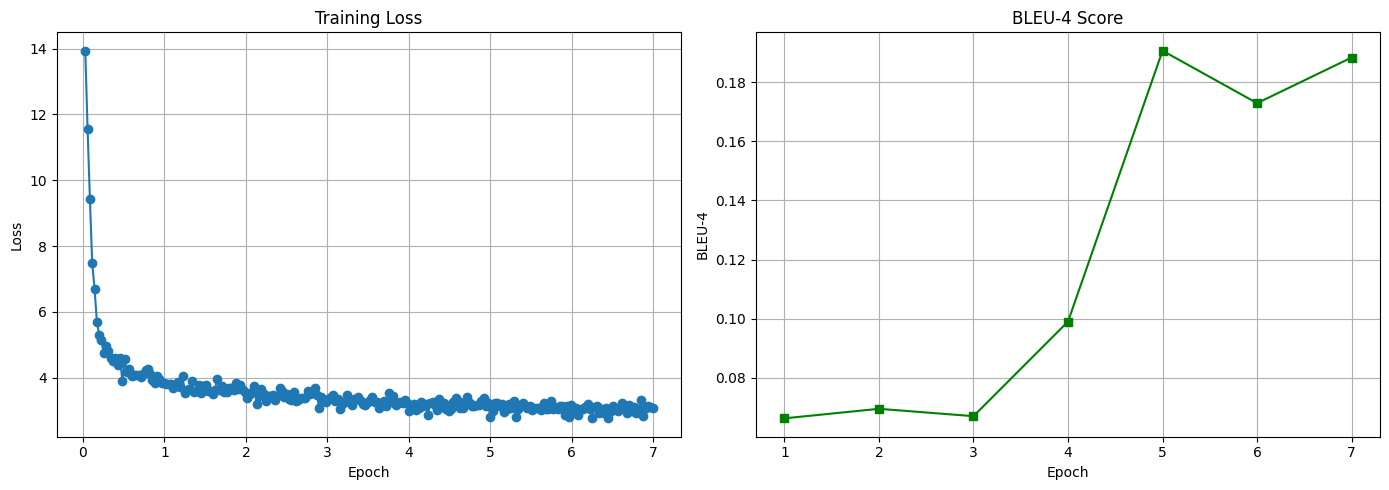

In [11]:
# Save adapter weights
adapter_save_path = trainer.save_adapter(
    adapter_name='mcq_generation',
    save_config={
        "model_name": "LazarusNLP/IndoNanoT5-base",
        "adapter_config": "pfeiffer",
        "reduction_factor": 12,
        "trainable_params": trainable,
        "total_params": total,
        "num_train_epochs": 8,
        "learning_rate": 1e-4,
        "training_time_hours": elapsed
    }
)

# Plot training curves
trainer.plot_training_curves(
    save_path=f'{CHECKPOINT_DIR}/training_curves.png'
)

## 8. Final Evaluation

In [12]:
# Re-initialize evaluator with trained model
evaluator_final = ModelEvaluator(
    model=model,
    tokenizer=tokenizer,
    metrics_calculator=metrics_calc
)

print('Running comprehensive evaluation on test set...')
final_metrics = evaluator_final.evaluate_on_test_set(
    test_dataset=test_dataset,
    num_beams=4,
    include_bertscore=True,
    max_samples=None
)

print('\n=== Evaluation Results ===')
for key, value in final_metrics.items():
    print(f'{key}: {value:.4f}')

Running comprehensive evaluation on test set...

EVALUATING ON TEST SET

Evaluating 352 samples...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: `past_key_value` is deprecated and will be removed in version 4.58 for `T5Block.forward`. Use `past_key_values` instead.
  result = forward_call(*args, **kwargs)


  Processed 10/352 samples...
  Processed 20/352 samples...
  Processed 30/352 samples...
  Processed 40/352 samples...
  Processed 50/352 samples...
  Processed 60/352 samples...
  Processed 70/352 samples...
  Processed 80/352 samples...
  Processed 90/352 samples...
  Processed 100/352 samples...
  Processed 110/352 samples...
  Processed 120/352 samples...
  Processed 130/352 samples...
  Processed 140/352 samples...
  Processed 150/352 samples...
  Processed 160/352 samples...
  Processed 170/352 samples...
  Processed 180/352 samples...
  Processed 190/352 samples...
  Processed 200/352 samples...
  Processed 210/352 samples...
  Processed 220/352 samples...
  Processed 230/352 samples...
  Processed 240/352 samples...
  Processed 250/352 samples...
  Processed 260/352 samples...
  Processed 270/352 samples...
  Processed 280/352 samples...
  Processed 290/352 samples...
  Processed 300/352 samples...
  Processed 310/352 samples...
  Processed 320/352 samples...
  Processed 330/3

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

  Computing Diversity...
✓ All metrics computed

Test Set Evaluation Results

BLEU Scores:
  BLEU:     0.1878
  BLEU-1:   0.5569
  BLEU-2:   0.3127
  BLEU-3:   0.1607
  BLEU-4:   0.0921

ROUGE Scores:
  ROUGE-1:  0.5107
  ROUGE-2:  0.2794
  ROUGE-L:  0.4426

BERTScore:
  Precision: 0.7931
  Recall:    0.7729
  F1:        0.7825

Diversity:
  Distinct-1: 0.1570
  Distinct-2: 0.5454


=== Evaluation Results ===
bleu: 0.1878
bleu_1: 0.5569
bleu_2: 0.3127
bleu_3: 0.1607
bleu_4: 0.0921
brevity_penalty: 0.8333
length_ratio: 0.8457
rouge_1: 0.5107
rouge_2: 0.2794
rouge_l: 0.4426
rouge_1_fmeasure: 0.5107
rouge_2_fmeasure: 0.2794
rouge_l_fmeasure: 0.4426
bertscore_precision: 0.7931
bertscore_recall: 0.7729
bertscore_f1: 0.7825
distinct_1: 0.1570
distinct_2: 0.5454


## 9. Generate Sample Outputs

In [13]:
EVAL_DIR = '/content/drive/MyDrive/dataset_aqg/evaluation_results_v3'

samples = evaluator_final.generate_samples(
    test_dataset=test_dataset,
    num_samples=20,
    num_beams=4,
    save_path=f'{EVAL_DIR}/sample_outputs.json'
)

print(f'✓ {len(samples)} samples generated')

# Preview first 3 samples
if samples:
    print('\n=== Sample Outputs ===')
    for i, sample in enumerate(samples[:3], 1):
        print(f"\n--- Sample {i} ---")
        print(f"Input: {sample['input']}...")
        print(f"Generated: {sample['generated']}...")


Generating 20 sample outputs...

--- Sample 1 ---
Input: buat_soal_pilihan_ganda: Duck typing tidak berkaitan langsung dengan dynamic typing atau loosely typed. Konsep duck typing lebih erat dengan pemrogram...
Reference: question: Dengan konsep apa duck typing lebih erat kaitannya?
answer: Pemrograman berorientasi objek (OOP)
distractors: Dynamic typing | Loosely typed...
Prediction: question: apa yang dimaksud dengan duck typing? answer: dynamic typing lebih erat dengan pemrograman berorientasi objek (oop) dan fokus pada kemampuan...
BLEU: 0.0000

--- Sample 2 ---
Input: buat_soal_pilihan_ganda: Notebook seperti Jupyter atau Colab menyediakan lingkungan pengembangan interaktif dengan sel-sel yang dapat dijalankan satu ...
Reference: question: Apa keunggulan sistem sel pada Notebook?
answer: Dapat menjalankan kode satu per satu
distractors: Lebih cepat dari script | Tidak perlu Pyt...
Prediction: question: apa yang dimaksud dengan jupyter atau colab? answer: lingkungan pengembangan i

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/dataset_aqg/evaluation_results_v3/sample_outputs.json'

## 10. Final Summary

In [14]:
import json
from pathlib import Path

# Compare with baseline
comparison = evaluator_final.compare_with_baseline(
    finetuned_metrics=final_metrics,
    baseline_metrics=baseline_metrics
)

# Save evaluation report
Path(EVAL_DIR).mkdir(parents=True, exist_ok=True)
report = {
    'version': '3.0 (Adapter Layers)',
    'baseline_metrics': baseline_metrics,
    'final_metrics': final_metrics,
    'comparison': comparison,
    'training_time_hours': elapsed,
    'adapter_path': adapter_save_path,
    'config': {
        'adapter_config': 'pfeiffer',
        'reduction_factor': 12,
        'learning_rate': 1e-4,
        'batch_size': 8,
        'epochs': 8
    }
}

with open(f'{EVAL_DIR}/evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

# Print summary
print('\n' + '='*60)
print('ADAPTER-BASED AQG TRAINING SUMMARY')
print('='*60)
print(f'Method: Adapter Layers (d=64)')
print(f'Training Time: {elapsed:.2f} hours')
print(f'Trainable: {100*trainable/total:.2f}%')
print(f'\nMetrics Comparison:')
print(f"  BLEU-4:  {baseline_metrics.get('bleu_4',0):.4f} → {final_metrics.get('bleu_4',0):.4f}")
print(f"  ROUGE-L: {baseline_metrics.get('rouge_l',0):.4f} → {final_metrics.get('rouge_l',0):.4f}")

bleu_improvement = comparison.get('bleu_4_improvement_pct', 0)
print(f'\nBLEU-4 Improvement: {bleu_improvement:+.1f}%')

if final_metrics.get('bleu_4', 0) >= 0.20:
    print('\n✓ SUCCESS: BLEU-4 target achieved (>= 0.20)')
else:
    print(f"\n⚠ BLEU-4 = {final_metrics.get('bleu_4',0):.4f} (target: >= 0.20)")
    print('  Consider: more epochs or adjust hyperparameters')

print('\n✓ Fine-tuning pipeline complete!')
print(f'  Adapter: {adapter_save_path}')
print(f'  Report: {EVAL_DIR}/evaluation_report.json')
print(f'  Samples: {EVAL_DIR}/sample_outputs.json')

print('\n' + '='*60)
print('HOW TO LOAD TRAINED ADAPTER')
print('='*60)
print('from adapters import AutoAdapterModel')
print('from transformers import AutoTokenizer')
print('')
print('model = AutoAdapterModel.from_pretrained("LazarusNLP/IndoNanoT5-base")')
print('tokenizer = AutoTokenizer.from_pretrained("LazarusNLP/IndoNanoT5-base")')
print(f'model.load_adapter("{adapter_save_path}")')
print('model.set_active_adapters("mcq_generation")')
print('')
print('# Generate')
print('inputs = tokenizer("generate_mcq: [CONTEXT]", return_tensors="pt")')
print('outputs = model.generate(**inputs, max_length=512, num_beams=4)')
print('print(tokenizer.decode(outputs[0], skip_special_tokens=True))')


COMPARING WITH BASELINE

Metric                        Baseline   Fine-tuned  Improvement
-----------------------------------------------------------------
bleu                            0.0233       0.1878      705.99%
bleu_1                          0.0993       0.5569      460.76%
bleu_2                          0.0331       0.3127      844.69%
bleu_3                          0.0124       0.1607     1194.74%
bleu_4                          0.0072       0.0921     1176.22%
brevity_penalty                 1.0000       0.8333      -16.67%
length_ratio                    1.6734       0.8457      -49.46%
rouge_1                         0.1687       0.5107      202.80%
rouge_2                         0.0462       0.2794      504.78%
rouge_l                         0.1446       0.4426      206.08%
rouge_1_fmeasure                0.1687       0.5107      202.80%
rouge_2_fmeasure                0.0462       0.2794      504.78%
rouge_l_fmeasure                0.1446       0.4426      206.08